First 5 Rows
   Product_id  Price  Sale  weight  resoloution  ppi  cpu core  cpu freq  \
0         203   2357    10   135.0          5.2  424         8      1.35   
1         880   1749    10   125.0          4.0  233         2      1.30   
2          40   1916    10   110.0          4.7  312         4      1.20   
3          99   1315    11   118.5          4.0  233         2      1.30   
4         880   1749    11   125.0          4.0  233         2      1.30   

   internal mem    ram  RearCam  Front_Cam  battery  thickness  
0          16.0  3.000    13.00        8.0     2610        7.4  
1           4.0  1.000     3.15        0.0     1700        9.9  
2           8.0  1.500    13.00        5.0     2000        7.6  
3           4.0  0.512     3.15        0.0     1400       11.0  
4           4.0  1.000     3.15        0.0     1700        9.9  


Last 5 Rows
     Product_id  Price  Sale  weight  resoloution  ppi  cpu core  cpu freq  \
156        1206   3551  4638   178.0         5.4

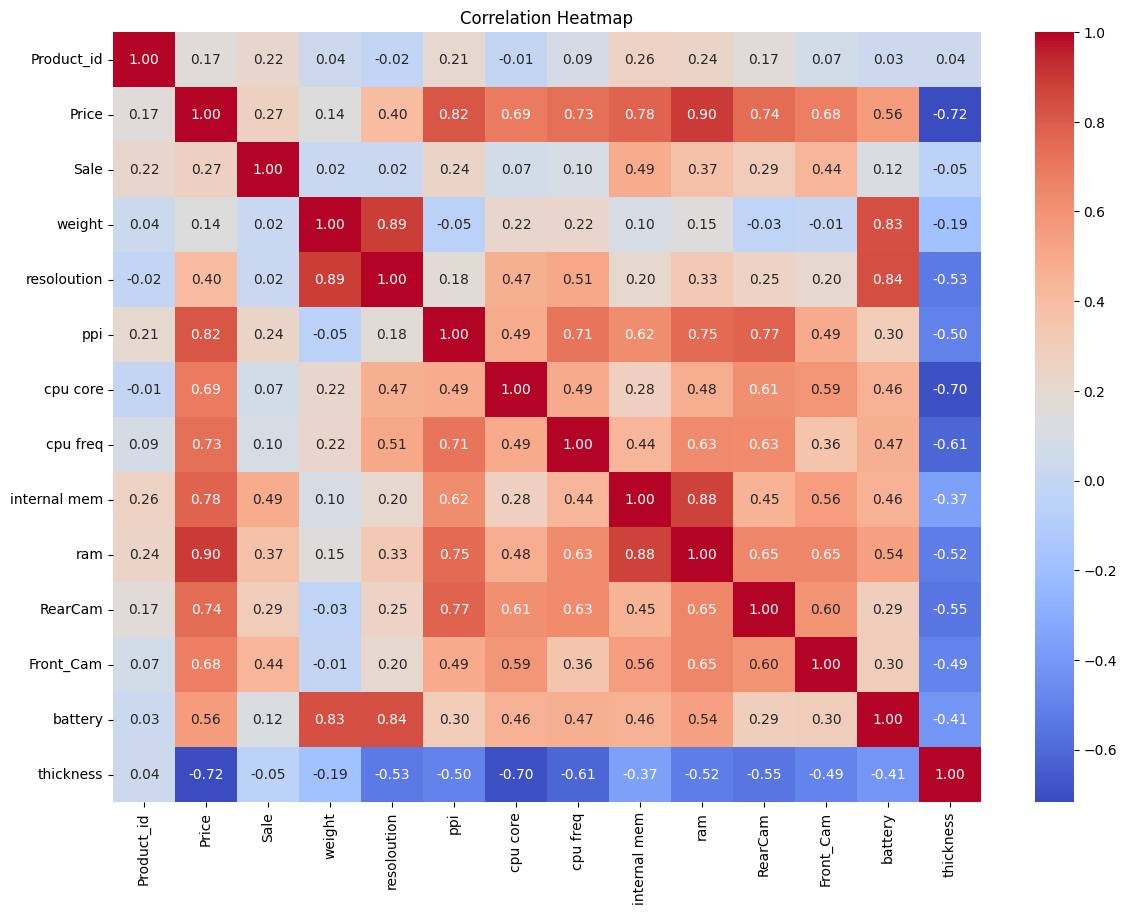

Correlation with Price
Price           1.000000
ram             0.896915
ppi             0.817614
internal mem    0.776738
RearCam         0.739538
cpu freq        0.727383
cpu core        0.686811
Front_Cam       0.675286
battery         0.559946
resoloution     0.404010
Sale            0.273263
Product_id      0.165136
weight          0.144555
thickness      -0.716773
Name: Price, dtype: float64


Top 4 Features Correlated with Price
ram             0.896915
ppi             0.817614
internal mem    0.776738
RearCam         0.739538
Name: Price, dtype: float64


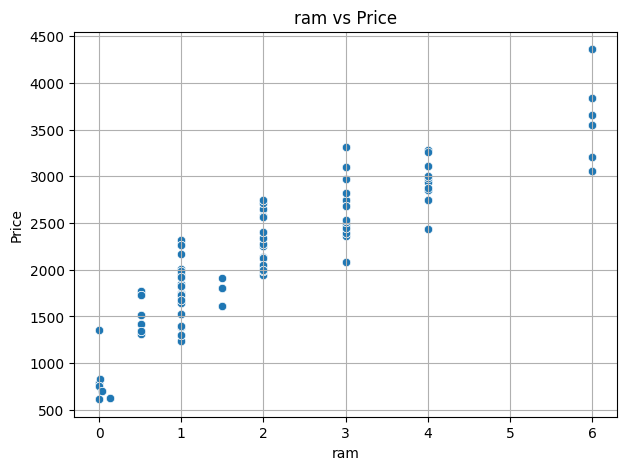

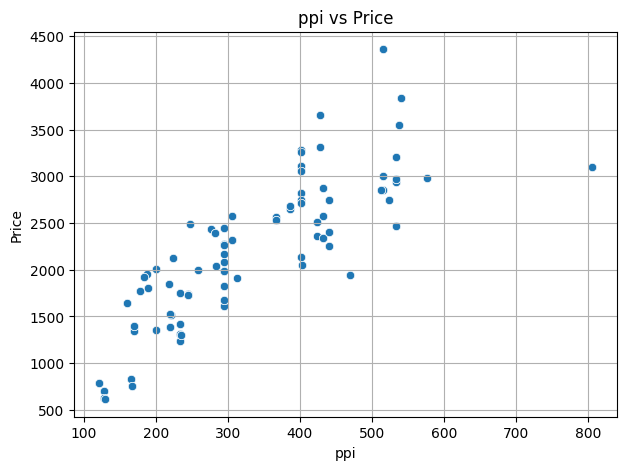

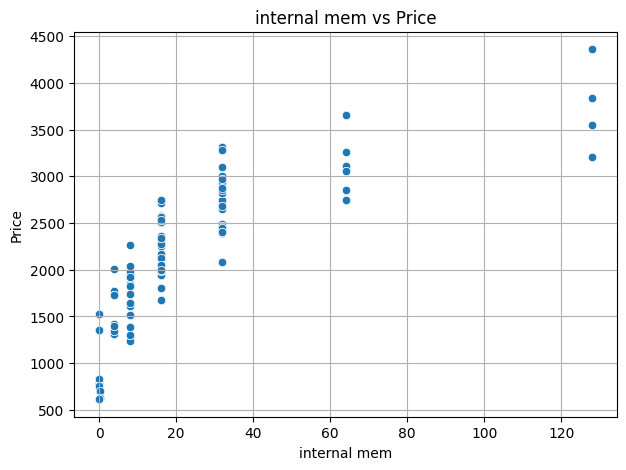

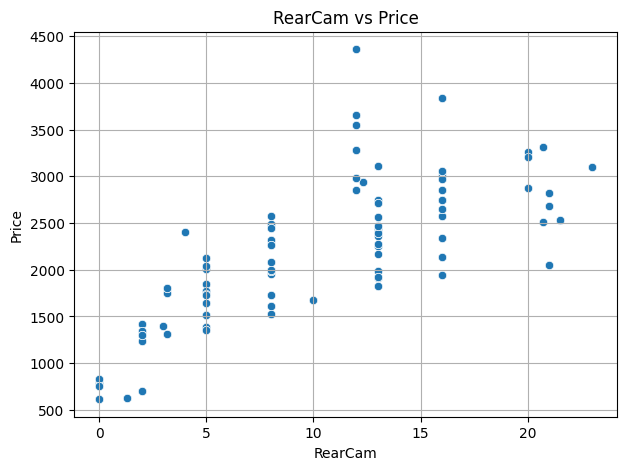



Features
   Product_id  Sale  weight  resoloution  ppi  cpu core  cpu freq  \
0         203    10   135.0          5.2  424         8      1.35   
1         880    10   125.0          4.0  233         2      1.30   
2          40    10   110.0          4.7  312         4      1.20   
3          99    11   118.5          4.0  233         2      1.30   
4         880    11   125.0          4.0  233         2      1.30   

   internal mem    ram  RearCam  Front_Cam  battery  thickness  
0          16.0  3.000    13.00        8.0     2610        7.4  
1           4.0  1.000     3.15        0.0     1700        9.9  
2           8.0  1.500    13.00        5.0     2000        7.6  
3           4.0  0.512     3.15        0.0     1400       11.0  
4           4.0  1.000     3.15        0.0     1700        9.9  


Target
0    2357
1    1749
2    1916
3    1315
4    1749
Name: Price, dtype: int64


Training Data Shape
(128, 13)


Testing Data Shape
(33, 13)


Model Trained Successfully


Slope 

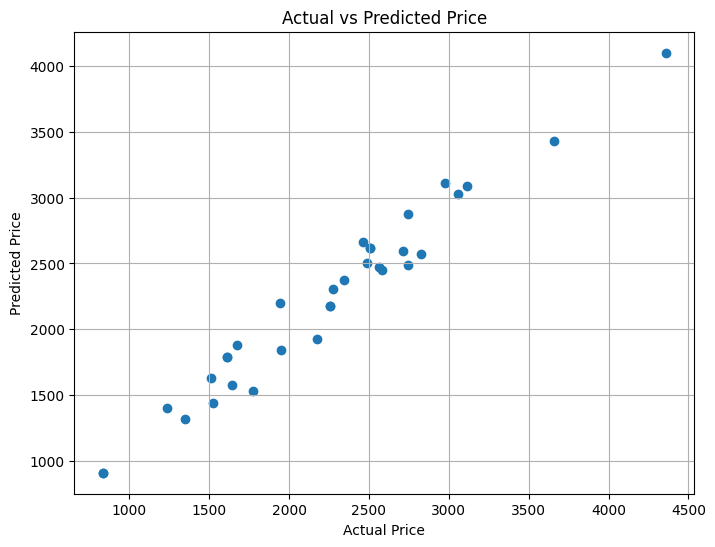

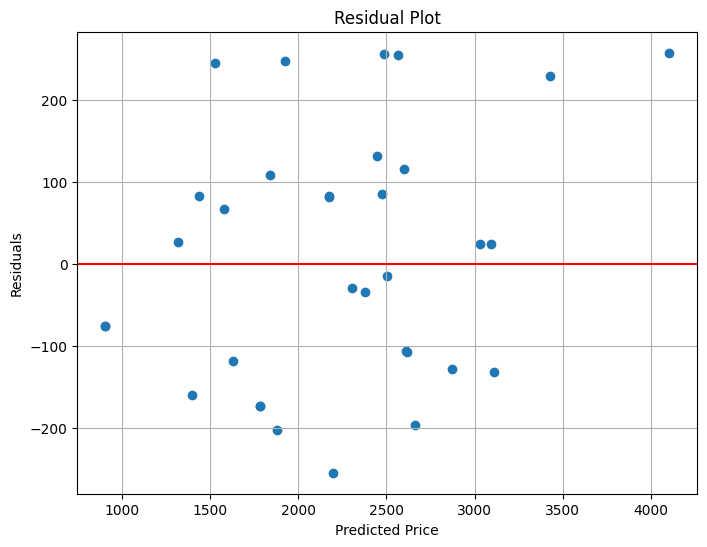



MODEL EVALUATION SUMMARY

Intercept
1629.0911226214037

Slope (Coefficients)
         Feature  Coefficient
0     Product_id     0.053807
1           Sale    -0.018289
2         weight    -0.881592
3    resoloution   -50.944081
4            ppi     1.108220
5       cpu core    49.312404
6       cpu freq   126.691872
7   internal mem     5.265144
8            ram   100.906852
9        RearCam     2.552383
10     Front_Cam     7.686950
11       battery     0.136214
12     thickness   -70.163939

R2 Score : 0.9593179111625717
Mean Absolute Error : 130.31530961030884
Mean Squared Error : 23062.229891751485

Excellent Prediction Accuracy

INSIGHTS

1. The correlation heatmap shows how each feature is related to Price.

2. The top four correlated features contribute the most to predicting mobile prices.

3. Scatter plots show the relationship between important features and Price.

4. Positive coefficients indicate that an increase in that feature increases the mobile price.

5. Negative coe

In [ ]:

# Assignment 6: Mobile Price Prediction using Linear Regression


# Step 1: Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Display all columns
pd.set_option('display.max_columns', None)

# Step 2: Load Dataset


url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/mobile_price.csv"

df = pd.read_csv(url)


# Step 3: Explore Dataset


print("="*60)
print("First 5 Rows")
print("="*60)
print(df.head())

print("\n")

print("="*60)
print("Last 5 Rows")
print("="*60)
print(df.tail())

print("\n")

print("="*60)
print("Dataset Shape")
print("="*60)
print(df.shape)

print("\n")

print("="*60)
print("Columns")
print("="*60)
print(df.columns)

print("\n")

print("="*60)
print("Data Types")
print("="*60)
print(df.dtypes)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)
print(df.info())

print("\n")

print("="*60)
print("Missing Values")
print("="*60)
print(df.isnull().sum())

print("\n")

print("="*60)
print("Duplicate Rows")
print("="*60)
print(df.duplicated().sum())

print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)
print(df.describe())

# Step 4: Correlation Heatmap


correlation = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


# Step 5: Correlation with Price


print("="*60)
print("Correlation with Price")
print("="*60)

price_corr = correlation["Price"].sort_values(ascending=False)

print(price_corr)

print("\n")

top_features = price_corr.drop("Price").head(4)

print("="*60)
print("Top 4 Features Correlated with Price")
print("="*60)
print(top_features)

# Step 6: Scatter Plots

for feature in top_features.index:

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        x=df[feature],
        y=df["Price"]
    )

    plt.title(feature + " vs Price")

    plt.xlabel(feature)

    plt.ylabel("Price")

    plt.grid(True)

    plt.show()


# Step 7: Feature Selection


X = df.drop("Price", axis=1)

y = df["Price"]

print("\n")

print("="*60)
print("Features")
print("="*60)
print(X.head())

print("\n")

print("="*60)
print("Target")
print("="*60)
print(y.head())


# Step 8: Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n")

print("="*60)
print("Training Data Shape")
print("="*60)
print(X_train.shape)

print("\n")

print("="*60)
print("Testing Data Shape")
print("="*60)
print(X_test.shape)

# Step 9: Build Linear Regression Model


model = LinearRegression()


# Step 10: Train Model


model.fit(X_train, y_train)

print("\n")

print("="*60)
print("Model Trained Successfully")
print("="*60)

# Step 11: Prediction


y_pred = model.predict(X_test)

# Step 12: Coefficients


print("\n")

print("="*60)
print("Slope (Coefficient)")
print("="*60)

coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_

})

print(coefficients)

# -----------------------------
# Step 13: Intercept
# -----------------------------

print("\n")

print("="*60)
print("Intercept")
print("="*60)

print(model.intercept_)

# -----------------------------
# Step 14: Evaluation Metrics
# -----------------------------

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

print("\n")

print("="*60)
print("Model Performance")
print("="*60)

print("R2 Score :", r2)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

# -----------------------------
# Step 15: Actual vs Predicted
# -----------------------------

result = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": y_pred

})

print("\n")

print("="*60)
print("Actual vs Predicted")
print("="*60)

print(result.head(20))


# Step 16: Actual vs Predicted Plot


plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.grid(True)

plt.show()


# Step 17: Residual Plot

residual = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residual
)

plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

# Step 18: Conclusion

print("\n")

print("="*70)
print("MODEL EVALUATION SUMMARY")
print("="*70)

print()

print("Intercept")
print(model.intercept_)

print()

print("Slope (Coefficients)")
print(coefficients)

print()

print("R2 Score :", r2)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print()

if r2 >= 0.90:
    print("Excellent Prediction Accuracy")

elif r2 >= 0.75:
    print("Good Prediction Accuracy")

elif r2 >= 0.60:
    print("Average Prediction Accuracy")

else:
    print("Model Needs Improvement")

print()

print("="*70)
print("INSIGHTS")
print("="*70)

print()

print("1. The correlation heatmap shows how each feature is related to Price.")

print()

print("2. The top four correlated features contribute the most to predicting mobile prices.")

print()

print("3. Scatter plots show the relationship between important features and Price.")

print()

print("4. Positive coefficients indicate that an increase in that feature increases the mobile price.")

print()

print("5. Negative coefficients indicate an inverse relationship with Price.")

print()

print("6. The intercept is the predicted price when all feature values are zero.")

print()

print("7. A higher R2 Score indicates a better model fit.")

print()

print("8. Lower MAE and MSE indicate better prediction accuracy.")

print()

print("9. Actual and Predicted values should be close for a good model.")

print()

print("10. Model performance can be improved using Feature Scaling, Feature Engineering, Random Forest Regression, XGBoost, or Hyperparameter Tuning.")

print()

print("="*70)
print("Assignment Completed Successfully")
print("="*70)